# 1. Import Libraries

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 2. Load Dataset

In [17]:
df = pd.read_csv("loan_approval_data.csv")

# 3. Initial Data Understanding

In [18]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# 4. Initial EDA - exploratory data analysis

Text(0.5, 1.0, 'Is Loan approved or not?')

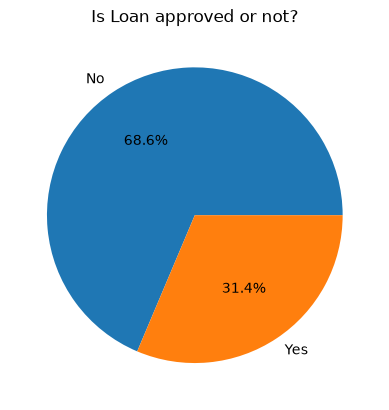

In [19]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

[Text(0, 0, '672'), Text(0, 0, '278')]

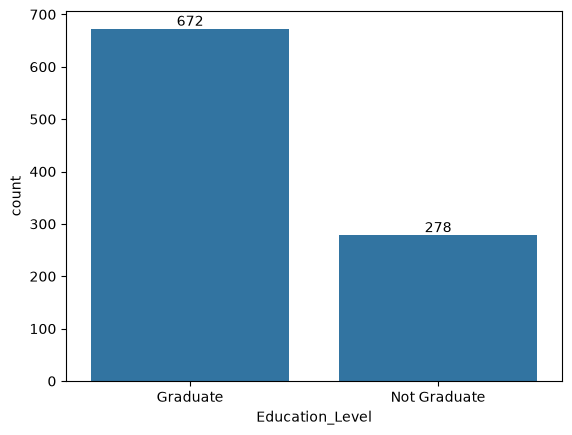

In [20]:
# analyze categories

# gender_cnt = df["Gender"].value_counts()
# ax = sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0])

edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

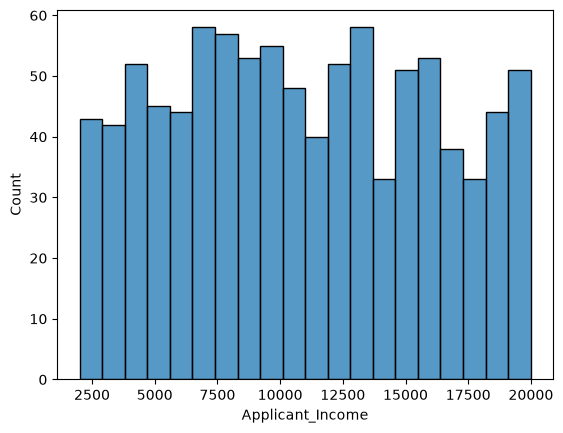

In [21]:
# analyze income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

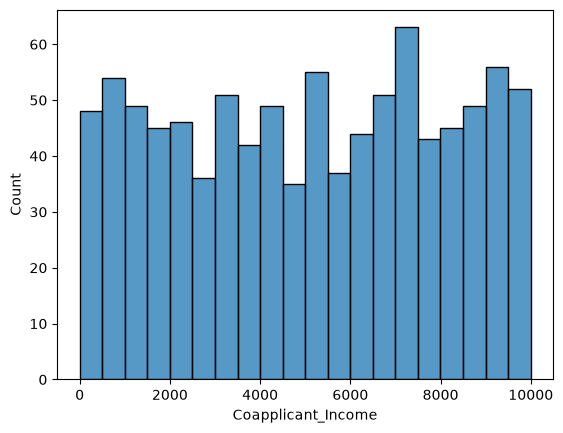

In [22]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

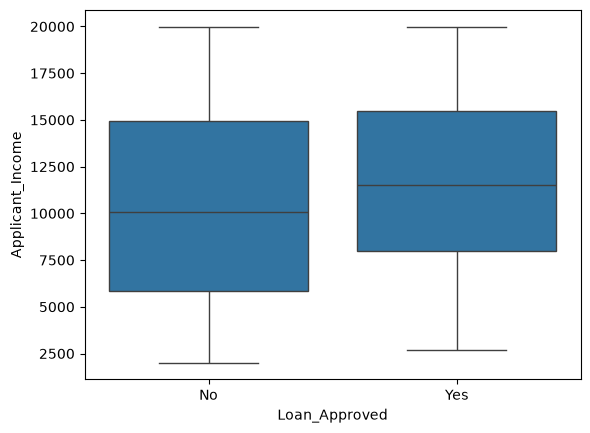

In [23]:
# outliers - box plots

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

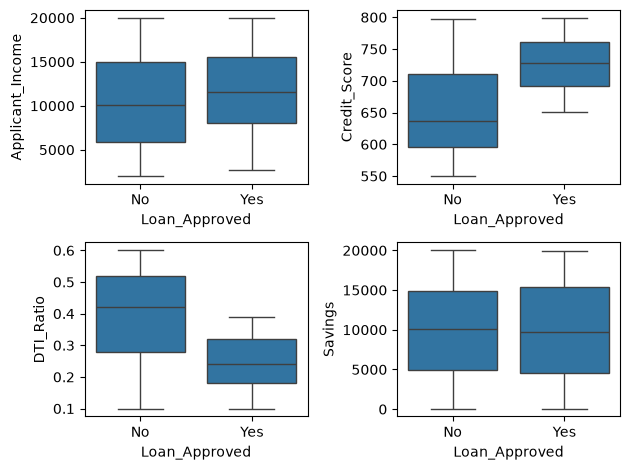

In [24]:
fig, axes = plt.subplots(2, 2)

sns.boxplot(ax=axes[0, 0], data=df, x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0, 1], data=df, x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1, 0], data=df, x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1, 1], data=df, x="Loan_Approved",y="Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

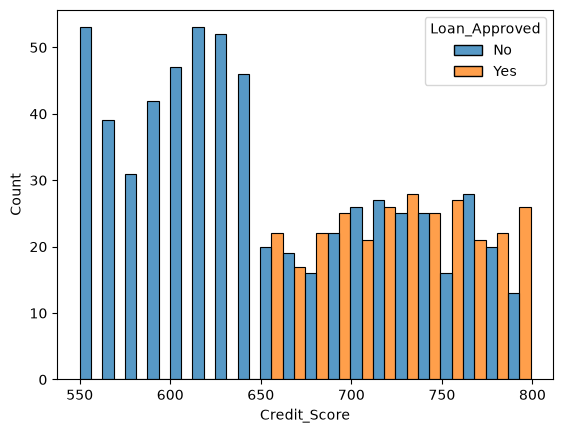

In [25]:
# Credit Score with Loan Approved

sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

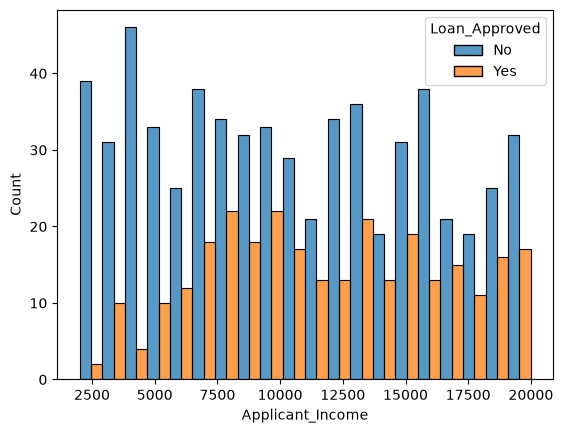

In [26]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

# 5. Separate Features & target

In [27]:
df = df.dropna(subset=["Loan_Approved"])

In [28]:
# Remove Applicant Id
df = df.drop("Applicant_ID", axis=1)

In [29]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# 6. Train-Test-Split

In [30]:
df["Loan_Approved"] = df["Loan_Approved"].map({
    "No": 0,
    "Yes": 1
})

In [31]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [ ]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_test.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category
153,7791.0,7138.0,Contract,47.0,Married,2.0,775.0,1.0,0.28,NaN,23949.0,21505.0,48.0,NaN,Rural,Not Graduate,Male,MNC
664,10150.0,6924.0,Salaried,57.0,Single,1.0,669.0,1.0,0.39,9884.0,17718.0,11528.0,12.0,Education,Rural,Graduate,Female,Private
376,18347.0,7424.0,Self-employed,35.0,Single,3.0,589.0,1.0,0.53,19464.0,2036.0,28621.0,36.0,Business,Semiurban,NaN,Male,Business
890,13694.0,8453.0,Salaried,50.0,Single,0.0,797.0,4.0,0.24,9877.0,49116.0,NaN,12.0,Home,Urban,Not Graduate,Female,MNC
589,10427.0,2203.0,Salaried,27.0,Single,3.0,784.0,1.0,0.19,NaN,2611.0,8878.0,72.0,Home,Urban,Graduate,Male,MNC


### Correlation heatmap

In [ ]:
numerical_cols = X.select_dtypes(include="number").columns

corr_data = pd.concat(
    [X[numerical_cols], y.rename("Loan_Approved")],
    axis=1
)

corr_data.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved         1.000000
Credit_Score          0.489880
Applicant_Income      0.127922
Collateral_Value      0.028128
Coapplicant_Income    0.009340
Dependents           -0.016541
Savings              -0.017319
Age                  -0.028058
Existing_Loans       -0.036184
Loan_Term            -0.092600
Loan_Amount          -0.130477
DTI_Ratio            -0.472434
Name: Loan_Approved, dtype: float64

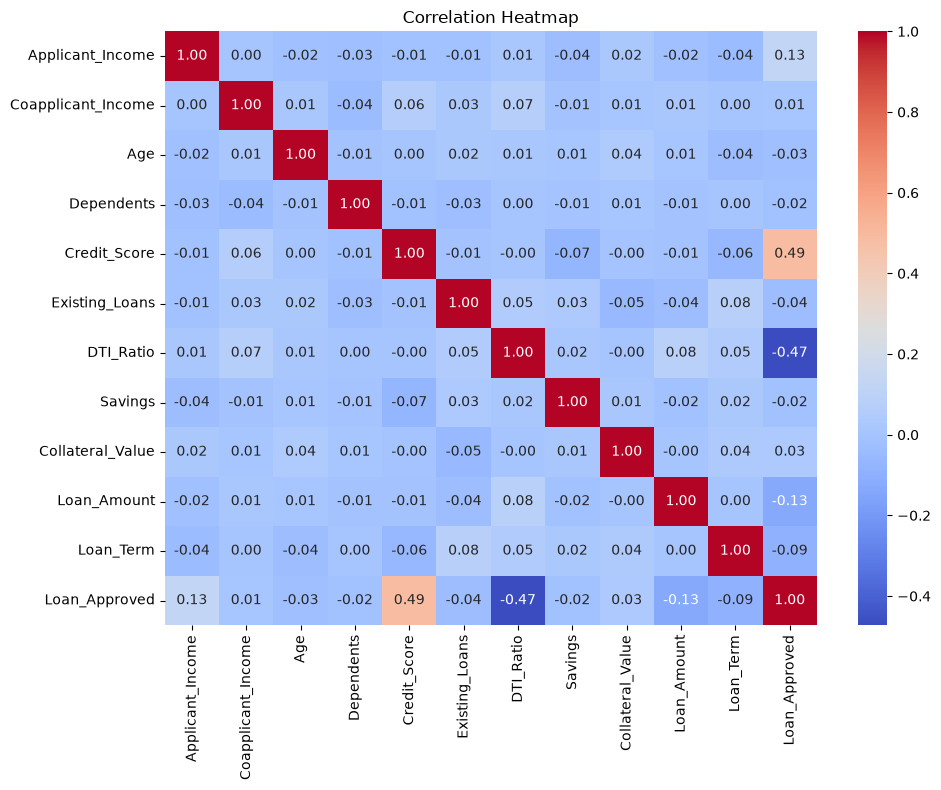

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

# 7. Missing Value Handling

In [ ]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["number"]).columns

C:\Users\KAIF\AppData\Local\Temp\ipykernel_13192\2120266143.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [ ]:
# Numerical missing values

from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")

X_train[numerical_cols] = num_imp.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = num_imp.transform(
    X_test[numerical_cols]
)

In [ ]:
# Categorical missing values

cat_imp = SimpleImputer(strategy="most_frequent")

X_train[categorical_cols] = cat_imp.fit_transform(
    X_train[categorical_cols]
)

X_test[categorical_cols] = cat_imp.transform(
    X_test[categorical_cols]
)

# 8. Define Feature Types from X

In [ ]:
numerical_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(exclude="number").columns

In [ ]:
print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols) 

Numerical columns:
Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')

Categorical columns:
Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category'],
      dtype='str')


# 9. Build the preprocessing pipelines

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

education_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["Not Graduate", "Graduate"]]
    ))
])

# 10. Combine them with ColumnTransformer

In [ ]:
from sklearn.compose import ColumnTransformer

numerical_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(include=["str"]).columns

ordinal_cols = ["Education_Level"]
nominal_cols = categorical_cols.difference(ordinal_cols)

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_cols),
    ("edu", education_pipeline, ordinal_cols),
    ("cat", nominal_pipeline, nominal_cols)
])

# 11. Build the model pipeline

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

In [ ]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Applicant_Income','Coapplicant_Income','Employment_Status',..., 'Education_Level','Gender','Employer_Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('edu', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [ ]:
y_pred_logistic = logistic_pipeline.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

In [ ]:
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Applicant_Income','Coapplicant_Income','Employment_Status',..., 'Education_Level','Gender','Employer_Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('edu', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [ ]:
y_pred_knn = knn_pipeline.predict(X_test)

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

In [ ]:
nb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['Applicant_Income','Coapplicant_Income','Employment_Status',..., 'Education_Level','Gender','Employer_Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('edu', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [ ]:
y_pred_nb = nb_pipeline.predict(X_test)

# 12. Evaluate

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nb)
    ],
    "confusion_matrix": [
        confusion_matrix(y_test, y_pred_logistic),
        confusion_matrix(y_test, y_pred_knn),
        confusion_matrix(y_test, y_pred_nb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,confusion_matrix
0,Logistic Regression,0.889474,0.854545,0.783333,0.817391,"[[122, 8], [13, 47]]"
1,KNN,0.821053,0.750000,0.650000,0.696429,"[[117, 13], [21, 39]]"
2,Naive Bayes,0.873684,0.860000,0.716667,0.781818,"[[123, 7], [17, 43]]"


# 13. Feature Engineering

In [ ]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["DTI_Ratio_sq"] = X_train["DTI_Ratio"] ** 2
X_test["DTI_Ratio_sq"] = X_test["DTI_Ratio"] ** 2

X_train["Credit_Score_sq"] = X_train["Credit_Score"] ** 2
X_test["Credit_Score_sq"] = X_test["Credit_Score"] ** 2

In [ ]:
numerical_cols = X_train.select_dtypes(include="number").columns
categorical_cols = X_train.select_dtypes(include=["str"]).columns

ordinal_cols = ["Education_Level"]
nominal_cols = categorical_cols.difference(ordinal_cols)

In [ ]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

education_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[["Not Graduate", "Graduate"]]
    ))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_cols),
    ("edu", education_pipeline, ordinal_cols),
    ("cat", nominal_pipeline, nominal_cols)
])

# 14. Retrain + Predict

In [ ]:
logistic_pipeline_fe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

logistic_pipeline_fe.fit(X_train, y_train)

y_pred_logistic_fe = logistic_pipeline_fe.predict(X_test)

In [ ]:
knn_pipeline_fe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_pipeline_fe.fit(X_train, y_train)

y_pred_knn_fe = knn_pipeline_fe.predict(X_test)

In [ ]:
nb_pipeline_fe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

nb_pipeline_fe.fit(X_train, y_train)

y_pred_nb_fe = nb_pipeline_fe.predict(X_test)

# 15 Re-evaluate the feature-engineered models

In [ ]:
print("Logistic Regression")
print("Precision:", precision_score(y_test, y_pred_logistic_fe))
print("Recall:", recall_score(y_test, y_pred_logistic_fe))
print("F1 Score:", f1_score(y_test, y_pred_logistic_fe))
print("Accuracy:", accuracy_score(y_test, y_pred_logistic_fe))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logistic_fe))

print("KNN")
print("Precision:", precision_score(y_test, y_pred_knn_fe))
print("Recall:", recall_score(y_test, y_pred_knn_fe))
print("F1 Score:", f1_score(y_test, y_pred_knn_fe))
print("Accuracy:", accuracy_score(y_test, y_pred_knn_fe))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn_fe))

print("Naive Bayes")
print("Precision:", precision_score(y_test, y_pred_nb_fe))
print("Recall:", recall_score(y_test, y_pred_nb_fe))
print("F1 Score:", f1_score(y_test, y_pred_nb_fe))
print("Accuracy:", accuracy_score(y_test, y_pred_nb_fe))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb_fe))    

Logistic Regression
Precision: 0.8596491228070176
Recall: 0.8166666666666667
F1 Score: 0.8376068376068376
Accuracy: 0.9
Confusion Matrix:
 [[122   8]
 [ 11  49]]
KNN
Precision: 0.7868852459016393
Recall: 0.8
F1 Score: 0.7933884297520661
Accuracy: 0.868421052631579
Confusion Matrix:
 [[117  13]
 [ 12  48]]
Naive Bayes
Precision: 0.8095238095238095
Recall: 0.85
F1 Score: 0.8292682926829268
Accuracy: 0.8894736842105263
Confusion Matrix:
 [[118  12]
 [  9  51]]


## ⚙️ Feature Engineering Result

Two additional nonlinear features were introduced:

- `DTI_Ratio²`
- `Credit_Score²`

The three models were retrained and evaluated after adding these features.

### Performance Before vs. After Feature Engineering

| Model | Baseline F1 | Feature-Engineered F1 | Improvement |
|---|---:|---:|---:|
| Logistic Regression | 83.76% | 83.76% | 0.00% |
| KNN | 79.34% | 79.34% | 0.00% |
| Naive Bayes | 82.93% | 82.93% | 0.00% |

Feature engineering did not change the test-set predictions or evaluation metrics of any of the three models.

Therefore, the added nonlinear features did not provide additional predictive benefit for this dataset.

# 16. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

In [ ]:
logistic_grid = GridSearchCV(
    logistic_pipeline_fe,
    param_grid=logistic_param_grid,
    cv=5,
    scoring="accuracy"
)

logistic_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [ ]:
print("Best Parameters:", logistic_grid.best_params_)
print("Best CV Score:", logistic_grid.best_score_)

Best Parameters: {'model__C': 100}
Best CV Score: 0.9039473684210526


In [ ]:
y_pred_logistic_tuned = logistic_grid.predict(X_test)

In [ ]:
print("Tuned Logistic Regression")
print("Precision:", precision_score(y_test, y_pred_logistic_tuned))
print("Recall:", recall_score(y_test, y_pred_logistic_tuned))
print("F1 Score:", f1_score(y_test, y_pred_logistic_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_logistic_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logistic_tuned))

Tuned Logistic Regression
Precision: 0.8153846153846154
Recall: 0.8833333333333333
F1 Score: 0.848
Accuracy: 0.9
Confusion Matrix:
 [[118  12]
 [  7  53]]


In [ ]:
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15]
}

In [ ]:
knn_grid = GridSearchCV(
    knn_pipeline_fe,
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy"
)

In [ ]:
knn_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

In [ ]:
print("Best Parameters:", knn_grid.best_params_)
print("Best CV Score:", knn_grid.best_score_)

Best Parameters: {'model__n_neighbors': 11}
Best CV Score: 0.8802631578947369


In [ ]:
y_pred_knn_tuned = knn_grid.predict(X_test)

In [ ]:
print("Tuned KNN")
print("Precision:", precision_score(y_test, y_pred_knn_tuned))
print("Recall:", recall_score(y_test, y_pred_knn_tuned))
print("F1 Score:", f1_score(y_test, y_pred_knn_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_knn_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn_tuned))

Tuned KNN
Precision: 0.8305084745762712
Recall: 0.8166666666666667
F1 Score: 0.8235294117647058
Accuracy: 0.8894736842105263
Confusion Matrix:
 [[120  10]
 [ 11  49]]


In [ ]:
nb_param_grid = {
    "model__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

In [ ]:
nb_grid = GridSearchCV(
    nb_pipeline_fe ,
    param_grid=nb_param_grid,
    cv=5,
    scoring="accuracy"
)

In [ ]:
nb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...aussianNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__var_smoothing': [1e-11, 1e-10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed

In [ ]:
print("Best Parameters:", nb_grid.best_params_)
print("Best CV Score:", nb_grid.best_score_)

Best Parameters: {'model__var_smoothing': 1e-11}
Best CV Score: 0.8894736842105264


In [ ]:
y_pred_nb_tuned = nb_grid.predict(X_test)

In [ ]:
print("Tuned Naive Bayes")
print("Precision:", precision_score(y_test, y_pred_nb_tuned))
print("Recall:", recall_score(y_test, y_pred_nb_tuned))
print("F1 Score:", f1_score(y_test, y_pred_nb_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_nb_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb_tuned))

Tuned Naive Bayes
Precision: 0.8095238095238095
Recall: 0.85
F1 Score: 0.8292682926829268
Accuracy: 0.8894736842105263
Confusion Matrix:
 [[118  12]
 [  9  51]]


In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic_tuned),
        accuracy_score(y_test, y_pred_knn_tuned),
        accuracy_score(y_test, y_pred_nb_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic_tuned),
        precision_score(y_test, y_pred_knn_tuned),
        precision_score(y_test, y_pred_nb_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic_tuned),
        recall_score(y_test, y_pred_knn_tuned),
        recall_score(y_test, y_pred_nb_tuned)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic_tuned),
        f1_score(y_test, y_pred_knn_tuned),
        f1_score(y_test, y_pred_nb_tuned)
    ]
})

final_results.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.900000,0.815385,0.883333,0.848000
2,Naive Bayes,0.889474,0.809524,0.850000,0.829268
1,KNN,0.889474,0.830508,0.816667,0.823529


# 17. Final Model Comparison

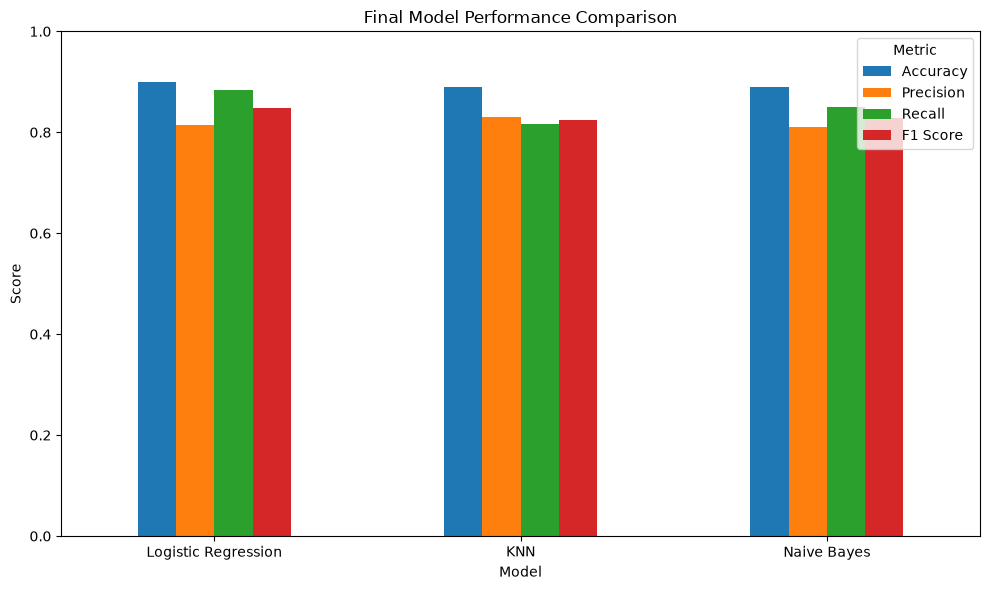

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

ax = final_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

## 18.🏆 Best Model Selection

After feature engineering and hyperparameter tuning, **Logistic Regression** was selected as the best overall model.

### Final Performance

| Metric | Score |
|---|---:|
| Accuracy | **90.00%** |
| Precision | 81.54% |
| Recall | **88.33%** |
| F1 Score | **84.80%** |

Logistic Regression achieved the highest **Accuracy, Recall, and F1 Score** among the three final tuned models.

KNN achieved the highest **Precision at 83.05%**, while Gaussian Naive Bayes achieved **80.95%**. Therefore, Logistic Regression was not selected because it had the highest precision.

For this loan approval problem, **precision is important because false-positive approvals represent cases where the model predicts a loan as approved when the actual class is rejected**. However, the project prioritizes an overall balance between precision and recall.

Since Logistic Regression achieved the highest **F1 Score**, along with the highest **Accuracy and Recall**, it was selected as the final model.

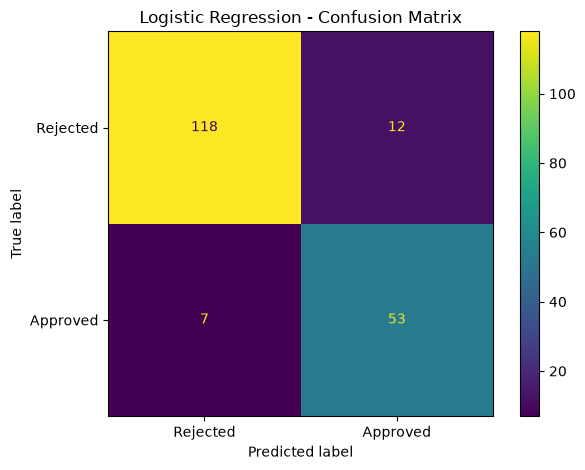

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic_tuned,
    display_labels=["Rejected", "Approved"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()

plt.show()

## 19. Conclusion

The CreditWise Loan Approval project compared Logistic Regression, K-Nearest Neighbors (KNN), and Gaussian Naive Bayes for predicting loan approval outcomes.

The project followed a complete supervised machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, model evaluation, and hyperparameter tuning using 5-fold cross-validation.

Two nonlinear features, `DTI_Ratio²` and `Credit_Score²`, were introduced during feature engineering. However, these additional features did not change the test-set predictions or evaluation metrics of the three models for this dataset.

After hyperparameter tuning, Logistic Regression achieved the best overall performance:

- Accuracy: **90.00%**
- Precision: **81.54%**
- Recall: **88.33%**
- F1 Score: **84.80%**

Logistic Regression achieved the highest Accuracy, Recall, and F1 Score among the three final tuned models, making it the strongest overall model.

Although precision is important for controlling incorrect loan approvals, the project considered the overall balance between precision and recall. Therefore, Logistic Regression was selected as the final model.

This project demonstrates the complete workflow of a supervised classification problem, from data understanding and preprocessing through feature engineering, model comparison, hyperparameter tuning, and final model selection.